In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_yaml = """
train: /content/drive/MyDrive/PedestrianDetection/images/train
val: /content/drive/MyDrive/PedestrianDetection/images/val
test: /content/drive/MyDrive/PedestrianDetection/images/test

nc: 2  # number of classes
names: ['pedestrian', 'other']  # replace with your class names
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8l.pt')   # switch from nano → large for better accuracy

model.train(
    data='data.yaml',
    epochs=200,              # train longer
    imgsz=1024,               # high-res improves small-object detection
    batch=8,
    patience=50,             # early stopping
    lr0=0.001,               # slightly lower LR for stability
    lrf=0.01,
    optimizer='AdamW',       # better for detection than SGD on many datasets

    # ------------ Augmentation ---------------
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,

    # ------------ Training Strategy -----------
    multi_scale=True,        # scales images between 0.5x–1.5x
    close_mosaic=10,         # stop mosaic near end of training
    cos_lr=True,             # cosine annealing
    rect=False,              # rectangular training = false for small objs

    # ------------ Output settings -------------
    project='/content/drive/MyDrive/PedestrianDetection/yolo8_results',
    name='yolo8l_cityscapes_optimized'
)

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=True, name=yolo8l_cityscapes_optimized, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=50, perspective=0.0005,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d822205f890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
bestModel = YOLO('/content/drive/MyDrive/PedestrianDetection/yolo8_results/yolo8l_cityscapes_optimized/weights/best.pt')

In [ ]:
bestModelPred = bestModel.predict(
    source='/content/drive/MyDrive/PedestrianDetection/images/test',
    save=True
)


image 1/500 /content/drive/MyDrive/PedestrianDetection/images/test/frankfurt_000000_000294_leftImg8bit.png: 512x1024 5 pedestrians, 1 other, 77.6ms
image 2/500 /content/drive/MyDrive/PedestrianDetection/images/test/frankfurt_000000_000576_leftImg8bit.png: 512x1024 2 others, 11.8ms
image 3/500 /content/drive/MyDrive/PedestrianDetection/images/test/frankfurt_000000_001016_leftImg8bit.png: 512x1024 2 pedestrians, 1 other, 11.9ms
image 4/500 /content/drive/MyDrive/PedestrianDetection/images/test/frankfurt_000000_001236_leftImg8bit.png: 512x1024 11 pedestrians, 1 other, 11.6ms
image 5/500 /content/drive/MyDrive/PedestrianDetection/images/test/frankfurt_000000_001751_leftImg8bit.png: 512x1024 1 pedestrian, 1 other, 11.7ms
image 6/500 /content/drive/MyDrive/PedestrianDetection/images/test/frankfurt_000000_002196_leftImg8bit.png: 512x1024 6 pedestrians, 1 other, 12.0ms
image 7/500 /content/drive/MyDrive/PedestrianDetection/images/test/frankfurt_000000_002963_leftImg8bit.png: 512x1024 (no dete

In [ ]:
import numpy as np
import torch
from torchvision import transforms
import pandas as pd
import os
from PIL import Image, ImageDraw
import shutil
import matplotlib.pyplot as plt

mask_dir = '/content/drive/MyDrive/PedestrianDetection/labels/testMask/all'
mask_result_dir = '/content/drive/MyDrive/PedestrianDetection/maskResultAll_GPU_Nov25'
os.makedirs(mask_result_dir, exist_ok=True)

mask_tensor_list = []
mask_result_tensor_list = []

transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize the image to 256x256
    transforms.ToTensor()           # Convert the image to a tensor
])

iou_score_list = []
for result in bestModelPred:
    print(result.boxes.xywh.cpu().numpy())
    res = result.boxes.xywh.cpu().numpy()
    print(result.orig_shape)
    mask_image = Image.new("L", (result.orig_shape[1], result.orig_shape[0]) , 0)

    for coord in res:
        x_center, y_center, w, h = coord
        x = x_center - w/2.0
        y = y_center - h/2.0
        draw = ImageDraw.Draw(mask_image)
        draw.rectangle([x, y, x + w, y + h], fill=255)

    mask_image.save(f"{mask_result_dir}/{result.path.split('/')[-1]}")
    image_result = transform(mask_image)
    mask_result_tensor_list.append(image_result)

    print(result.path.split("/")[-1])
    path = os.path.join(mask_dir, result.path.split("/")[-1])
    image = Image.open(path)
    image_expected = transform(image)
    mask_tensor_list.append(image_expected)

    intersection = torch.logical_and(image_result, image_expected).sum().item()
    union = torch.logical_or(image_result, image_expected).sum().item()

    iou_score = 0.0
    if union != 0:
        iou_score = intersection / union

    iou_score_list.append(iou_score)


[[     1240.4       424.8      36.393      97.222]
 [     1212.5      422.44      28.744      88.436]
 [     1176.2      422.67      34.778       97.62]
 [     1181.4      427.59      28.234      86.846]
 [     955.55       424.1      12.074      34.522]
 [     955.57         425       13.04      35.965]]
(1024, 2048)
frankfurt_000000_000294_leftImg8bit.png
[[       1217       415.9       48.11      116.42]
 [     1036.7      404.54      18.525      48.054]]
(1024, 2048)
frankfurt_000000_000576_leftImg8bit.png
[[     1504.4      437.53      118.96      275.01]
 [     952.78      438.79      64.537      153.67]
 [     764.46      447.17      88.894      242.34]]
(1024, 2048)
frankfurt_000000_001016_leftImg8bit.png
[[      692.3      430.62      46.063      108.41]
 [     824.88      416.48       30.41      75.157]
 [     1291.1      415.04      34.748      88.367]
 [     568.66      416.88      28.701       69.81]
 [     1010.8       407.7       26.84      85.861]
 [     534.82      415

In [ ]:
iou_score_list

[0.9146919431279621,
 0.924924924924925,
 0.8935315387705905,
 0.8219633943427621,
 0.5574387947269304,
 0.858433734939759,
 0.0,
 0.6372549019607843,
 0.0,
 0.13360323886639677,
 0.0,
 0.3861788617886179,
 0.6798029556650246,
 0.0,
 0.0,
 0.6014418125643667,
 0.7821195973949082,
 0.8506787330316742,
 0.7474429583005507,
 0.8155172413793104,
 0.9031567683253077,
 0.0,
 0.8928571428571429,
 0.9230769230769231,
 0.9504843918191603,
 0.7039274924471299,
 0.7298907646474677,
 0.9504587155963303,
 0.0,
 0.77965743286107,
 0.8895265423242468,
 0.8808022922636103,
 0.17158176943699732,
 0.7453416149068323,
 0.8937444543034605,
 0.7279411764705882,
 0.894878706199461,
 0.8372093023255814,
 0.7160647571606475,
 0.8634020618556701,
 0.10841546626231995,
 0.7291666666666666,
 0.836962590731435,
 0.81829814459373,
 0.8237054774019754,
 0.7772220084647942,
 0.3010752688172043,
 0.4810810810810811,
 0.8505586592178771,
 0.8954451345755694,
 0.8329682365826944,
 0.8904823989569752,
 0.576899320568252

<BarContainer object of 500 artists>

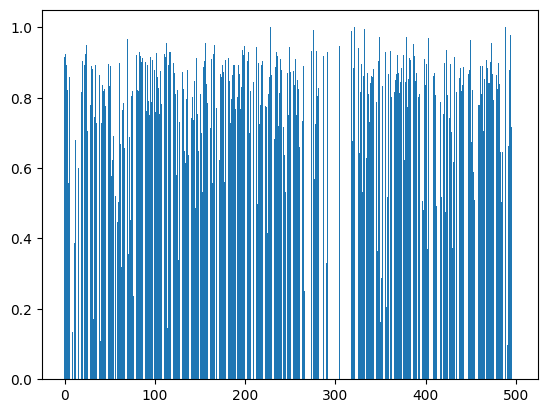

In [ ]:
plt.bar(range(len(iou_score_list)), iou_score_list)

In [ ]:
np.mean(iou_score_list)

np.float64(0.6699081862483008)